## Stoichiometric Compatibility in reaction `A <-> 2 B` elementary reversible decomposition reaction  

From different starting condition, we explore the stoichiometric compatibility class for this reaction, and observe that they follow 1-dimensional paths, as expected.  

**Background**  
We'll be following "Foundations of Chemical Reaction Network Theory" (2019), by Martin Feinberg, section 3.4

See also: experiment _"react_4"_ , for an intro to this reaction

### TAGS :  "uniform compartment"

In [1]:
LAST_REVISED = "Mar. 12, 2026"
LIFE123_VERSION = "1.0.0rc7"        # Library version this experiment is based on

In [2]:
#import set_path                    # Using MyBinder?  Uncomment this before running the next cell!

In [19]:
#import sys
#sys.path.append("C:/some_path/my_env_or_install")   # CHANGE to the folder containing your venv or libraries installation!
# NOTE: If any of the imports below can't find a module, uncomment the lines above, or try:  import set_path   

from life123 import check_version, ReactionRegistry, UniformCompartment, PlotlyHelper

In [4]:
check_version(LIFE123_VERSION)

OK


# PART 1 - simulation of the reaction

In [21]:
# Set up the reactions and their chemicals (common for all the simulations below)
rxns = ReactionRegistry()

# Elementary reaction A <-> 2 B
rxns.add_reaction(reactants="A", products=[(2, "B")], kF=3., kR=2.)

rxns.describe_reactions()

add_reaction(): detected reaction type `ReactionDecomposition`
Number of reactions: 1
0: A <-> 2 B  Elementary Decomposition reaction  (kF = 3 / kR = 2 / K = 1.5)
Chemicals involved in the above reactions: ['A', 'B']


In [22]:
# Instantiate the simulator with the predefined chemical species and set of reactions
uc = UniformCompartment(reactions=rxns, preset="fast")

# Initial concentrations of all the chemicals
uc.set_conc({"A": 40., "B": 0.})
uc.describe_state()

SYSTEM STATE at Time t = 0:
2 species:
  Species 0 (A). Conc: 40.0
  Species 1 (B). Conc: 0.0
Chemicals involved in reactions: ['B', 'A']


In [23]:
uc.get_history()

,SYSTEM TIME,A,B,step,caption
0,0.0,40.0,0.0,,Set concentration


### Let's look ahead at the final equilibrium point

In [24]:
uc.find_equilibrium_conc(rxn_index=0)    # This is an EXACT equilibrium solution, 
                                         # for 1 reaction (the only reaction)

{'A': 36.30998065768848, 'B': 7.38003868462305}

### Run the reaction

In [25]:
uc.single_compartment_react(initial_step=0.002, duration=0.15)    # Variable steps is the default

15 total variable step(s) taken in 0.034 sec
Norm usage: {'norm_A': 9, 'norm_B': 10, 'norm_C': 9, 'norm_D': 9}
System Time is now: 0.13642


In [26]:
df = uc.get_history()
df

,SYSTEM TIME,A,B,step,caption
0,0.000000,40.000000,0.000000,,Set concentration
1,0.002000,39.760000,0.480000,1,1st reaction step
2,0.005000,39.403542,1.192915,2,
3,0.007400,39.126668,1.746665,3,
4,0.009800,38.859600,2.280801,4,
5,0.012200,38.604780,2.790439,5,
6,0.014600,38.364201,3.271597,6,
7,0.017000,38.139355,3.721290,7,
8,0.020600,37.827156,4.345689,8,
9,0.024200,37.554594,4.890811,9,


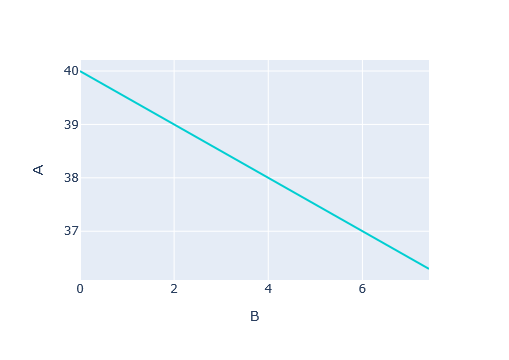

In [27]:
plot_1 = PlotlyHelper.plot_pandas(df=df, x_var="B", fields="A", show=True)

#### Because of the stoichiometry of A <-> 2B , for every molecule of `A` consumed, 2 of `B` are produced.  Hence, the linearity of `A` vs. `B` over time (in our scenario, the reaction starts in the upper left point, and attains equilibrium in the bottom right)

## More formally, the **stoichiometric compatibility class** of our reaction network (`A -> 2B` and `2B -> A`) is uni-dimensional.
And that's because our reaction vectors are {A−2B , 2B−A}, which are linearly dependent.

For more detailed explanations, see "Foundations of Chemical Reaction Network Theory" (2019), by Martin Feinberg, section 3.4

## Repeat, with a different start condition

In [28]:
# Instantiate the simulator with the predefined chemical species and set of reactions
uc = UniformCompartment(reactions=rxns, preset="fast")

# Initial concentrations of all the chemicals
uc.set_conc({"A": 30., "B": 0.})
uc.describe_state()

SYSTEM STATE at Time t = 0:
2 species:
  Species 0 (A). Conc: 30.0
  Species 1 (B). Conc: 0.0
Chemicals involved in reactions: ['B', 'A']


### Run the reaction

In [29]:
uc.single_compartment_react(initial_step=0.002, duration=0.15)    # Variable steps is the default

17 total variable step(s) taken in 0.037 sec
Norm usage: {'norm_A': 10, 'norm_B': 11, 'norm_C': 10, 'norm_D': 10}
System Time is now: 0.20333


In [30]:
df = uc.get_history()
df

,SYSTEM TIME,A,B,step,caption
0,0.000000,30.000000,0.000000,,Set concentration
1,0.002000,29.820000,0.360000,1,1st reaction step
2,0.005000,29.552398,0.895205,2,
3,0.007400,29.343467,1.313066,3,
4,0.009800,29.140470,1.719060,4,
5,0.012200,28.944843,2.110313,5,
6,0.014600,28.757817,2.484366,6,
7,0.017000,28.580387,2.839227,7,
8,0.020600,28.329759,3.340482,8,
9,0.024200,28.104141,3.791718,9,


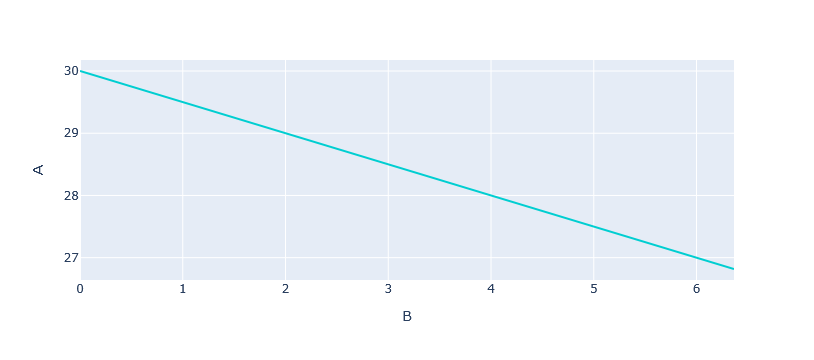

In [31]:
plot_2 = PlotlyHelper.plot_pandas(df=df, x_var="B", fields="A", show=True)

### Same linearity as before, but with different starting and ending points

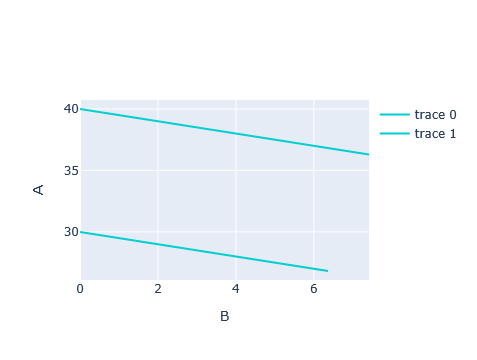

In [48]:
PlotlyHelper.combine_plots(fig_list=[plot_1, plot_2])

## Repeat a 3rd and 4th time, with a different start condition

In [34]:
# Instantiate the simulator with the predefined chemical species and set of reactions
uc = UniformCompartment(reactions=rxns, preset="fast")

# Initial concentrations of all the chemicals
uc.set_conc({"A": 10., "B": 0.})

In [35]:
uc.single_compartment_react(initial_step=0.002, duration=0.15)    # Variable steps is the default

18 total variable step(s) taken in 0.040 sec
Norm usage: {'norm_A': 9, 'norm_B': 10, 'norm_C': 9, 'norm_D': 9}
System Time is now: 0.15232


In [36]:
df = uc.get_history()

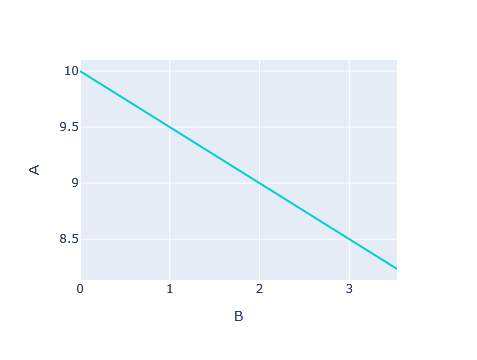

In [37]:
plot_3 = PlotlyHelper.plot_pandas(df=df, x_var="B", fields="A")

In [39]:
# Instantiate the simulator with the predefined chemical species and set of reactions
uc = UniformCompartment(reactions=rxns, preset="fast")

# Initial concentrations of all the chemicals
uc.set_conc({"A": 80., "B": 0.})

In [40]:
uc.single_compartment_react(initial_step=0.002, duration=0.15)    # Variable steps is the default

15 total variable step(s) taken in 0.032 sec
Norm usage: {'norm_A': 10, 'norm_B': 11, 'norm_C': 10, 'norm_D': 10}
System Time is now: 0.19433


In [41]:
df = uc.get_history()

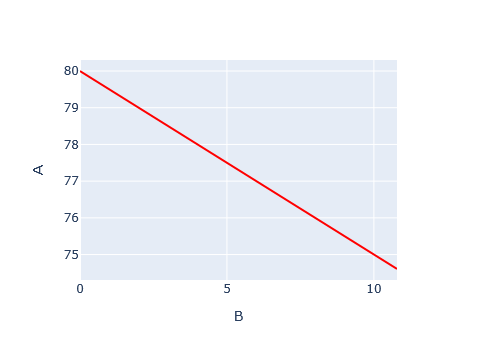

In [44]:
plot_4 = PlotlyHelper.plot_pandas(df=df, x_var="B", fields="A", colors="red")

### Finally, combine all plots

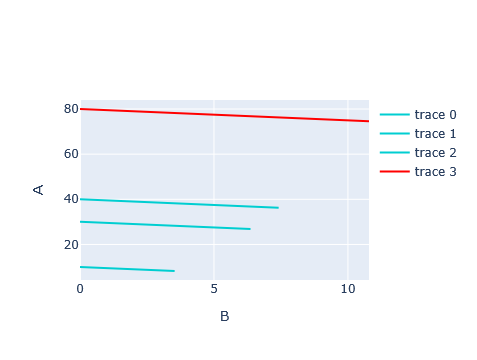

In [45]:
PlotlyHelper.combine_plots(fig_list=[plot_1, plot_2, plot_3, plot_4])

### Compare with the phase portrait in fig. 3.1 on page 32 of "Foundations of Chemical Reaction Network Theory" (2019), by Martin Feinberg 
(Here we're only doing a more limited run, and not approaching the equilibria points from the other side, i.e. with initial concentrations of just `B`)